In [1]:
# =====================================================================
# Part I - Finance - TEMPLATE
# =====================================================================
# The framework (finance_toolkit) fixes two things for everyone: how
# the data is loaded, and how a score panel is scored into a PnL,
# Sharpe and turnover.  Everything in the middle is yours.
#
# THE FLOW:
#   1. data is loaded for you (same for the whole class),
#   2. YOU build a SUPERSET of named features (FREE 1),
#   3. YOU write ONE recipe build_alpha(config) (FREE 2): a config
#      (feature subset, model, hyperparams) -> a trained model ->
#      scores -> positions -> its daily PnL,
#   4. YOU loop that recipe over MANY configs (FREE 3) to make many alphas,
#   5. the framework evaluates every alpha (Sharpe, turnover, ...),
#      shows the correlation between them, and keeps the best
#      un-correlated set.
#
# Your model only has to satisfy the MODEL CONTRACT:
#
#     model.predict(feat_t) -> scores
#     feat_t : float tensor (days, stocks, features)
#     scores : float tensor (days, stocks)
#
# Everything is a "panel": a table of shape (days x stocks).  Every
# operator takes panels and returns a panel of the same shape.

In [2]:
import os
import json
import numpy
import torch
import finance_toolkit as toolkit

# =====================================================================
# FIXED 1
# =====================================================================
SEED = 42
torch.manual_seed(SEED)
numpy.random.seed(SEED)
torch.set_num_threads(4)

# Everything up to SPLIT_DATE trains; the rest is a local hold-out
# you score yourself.  The instructor's HIDDEN slice is a separate,
# even later date range you never see.

DATA_DIR = "../data"
panels = toolkit.load_prices(DATA_DIR)

# This will be used for the target of the model.
forward_returns = toolkit.forward_return(panels["returns"])
mask = toolkit.valid_mask(panels, min_history=60)

all_dates = panels["close"].index
tickers = panels["close"].columns
print("panel:", panels["close"].shape, "dates",
      all_dates.min().date(), "to", all_dates.max().date())

# you may choose another split.
SPLIT_DATE = "2020-01-01"
is_train = all_dates < SPLIT_DATE
is_test = ~is_train
print("train days:", int(is_train.sum()),
      " test days:", int(is_test.sum()))


close = panels["close"]
open_ = panels["open"]
high = panels["high"]
low = panels["low"]
volume = panels["volume"]
returns = panels["returns"]
sector, industry = toolkit.load_groups("../data/groups.csv")

panel: (2669, 2994) dates 2013-01-02 to 2023-06-30
train days: 1775  test days: 894


In [3]:
# =====================================================================
# >>> FREE 1 <<<   your features
# =====================================================================
# 12 features across five families. Every one is now sector- (or, for
# the two originally industry-neutral reversal features, industry-)
# neutralized, per the assignment's tip: "Neutralise by sector to drop
# sector bets." Round-1 through round-3 only neutralized 3 of the
# original 13; the round-1 correlation diagnostic showed the biggest
# blocker in the whole search was mlp_all_b_s2 (blocked 15 of 27
# excluded-but-qualifying alphas, correlation up to 0.99 with its own
# near-duplicate) -- consistent with un-neutralized features sharing a
# common sector/market tilt that shows up as correlated PnL regardless
# of which specific feature combination a model uses.
#
# Sector-neutralizing mom_20 makes it mathematically identical to the
# old separately-named "sector_mom_20" (both were the same 20-day
# mean-return signal, one market-wide, one sector-neutral -- neutralize
# the first and they collapse into one), so that name is retired
# rather than kept as a duplicate: 13 features become 12.
#
#   momentum   -- mean return over 5/20/60 days, sector-neutral
#                 (mom_5, mom_20, mom_60)
#   reversal   -- yesterday's return negated, the worked intraday
#                 example, both sector-neutral; 5-day reversal within
#                 industry (finer-grained, already neutral)
#                 (rev_1, intraday_rev_20, industry_rev_5)
#   technical  -- position within the day's high/low range, the
#                 overnight open-vs-prior-close gap, deviation from
#                 the 20-day moving average -- all sector-neutral
#                 (range_pos, gap, price_to_ma20)
#   volatility -- 20-day realized vol, 20-day average relative
#                 high-low range -- sector-neutral
#                 (vol_20, high_low_range_20)
#   volume     -- today's volume z-scored against its own 20-day
#                 history, then sector-neutralized (volume_spike_20)
all_features = {
    "mom_5": toolkit.cs_zscore(toolkit.ts_mean(returns, 5), sector),
    "mom_20": toolkit.cs_zscore(toolkit.ts_mean(returns, 20), sector),
    "mom_60": toolkit.cs_zscore(toolkit.ts_mean(returns, 60), sector),
    "rev_1": toolkit.cs_zscore(-returns, sector),
    "intraday_rev_20": toolkit.cs_zscore(toolkit.ts_zscore(open_ - close, 20), sector),
    "industry_rev_5": toolkit.cs_zscore(-toolkit.ts_mean(returns, 5), industry),
    "range_pos": toolkit.cs_zscore((close - low) / (high - low), sector),
    "gap": toolkit.cs_zscore((open_ - close.shift(1)) / close.shift(1), sector),
    "price_to_ma20": toolkit.cs_zscore((close - toolkit.ts_mean(close, 20)) / toolkit.ts_mean(close, 20), sector),
    "vol_20": toolkit.cs_zscore(toolkit.ts_std(returns, 20), sector),
    "high_low_range_20": toolkit.cs_zscore(toolkit.ts_mean((high - low) / close, 20), sector),
    "volume_spike_20": toolkit.cs_zscore(toolkit.ts_zscore(volume, 20), sector),
}

all_feature_panel = toolkit.build_features(all_features, panels)
# float32 instead of pandas' default float64: halves the memory of
# every downstream stack/tensor built from these panels. This machine
# has 8GB RAM shared with other running apps, and stacking many
# features at float64 reliably fails with an out-of-memory error here
# (measured: a single ~800MB allocation at 13 features). The final
# model tensors are float32 regardless -- make_tensors casts
# explicitly -- so this only removes a redundant doubling, it never
# changes any result.
all_feature_panel = {k: v.astype("float32") for k, v in all_feature_panel.items()}
all_feature_names = sorted(all_feature_panel)
print("features available:", all_feature_names)

# Feature-family subsets: each is one hypothesis about what drives the
# 2-day-ahead return, so alphas built from different subsets start out
# making genuinely different bets (see FREE 3 for why this mattered).
momentum_set = ["mom_5", "mom_20", "mom_60"]
reversal_set = ["rev_1", "intraday_rev_20", "industry_rev_5"]
vol_volume_set = ["vol_20", "high_low_range_20", "volume_spike_20"]
technical_set = ["range_pos", "gap", "price_to_ma20"]
mixed_set = ["mom_20", "rev_1", "range_pos", "vol_20", "gap"]
all_set = all_feature_names

features available: ['gap', 'high_low_range_20', 'industry_rev_5', 'intraday_rev_20', 'mom_20', 'mom_5', 'mom_60', 'price_to_ma20', 'range_pos', 'rev_1', 'vol_20', 'volume_spike_20']


In [4]:
# =====================================================================
# >>> FREE 2 <<<   one recipe for building an alpha
# =====================================================================
# Two small subclasses first, then the recipe.
#
# Why subclass instead of using toolkit.MLP / toolkit.LSTM directly:
# finance_toolkit.predict_scores runs model.predict(feat_t) on the
# FULL (days, stocks, features) tensor in one shot -- no batching.
# For the LSTM that means one un-batched forward pass over ~2700 days
# x ~3000 stocks, which needs a single ~8GB allocation and reliably
# crashes on this 8GB machine (measured directly while developing
# this). predict_scores is part of the FIXED framework, so it can't
# be changed; instead these subclasses override only predict() to
# process the day axis in chunks (carrying LSTM hidden state across
# chunks), giving the exact same output with a small, bounded memory
# footprint. MLP.step() also calls self.predict() during training, so
# SafeMLP must NOT force no_grad in predict() or gradients break.


class SafeMLP(toolkit.MLP):
    def predict(self, x, chunk_days=300):
        outs = [toolkit.MLP.predict(self, x[start:start + chunk_days])
                for start in range(0, x.shape[0], chunk_days)]
        return torch.cat(outs, dim=0)


class SafeLSTM(toolkit.LSTM):
    def predict(self, x, chunk_days=150):
        outs, state = [], None
        with torch.no_grad():
            for start in range(0, x.shape[0], chunk_days):
                out, state = self.step(x[start:start + chunk_days], state)
                outs.append(out)
        return torch.cat(outs, dim=0)


def build_alpha(features, model_kind="lstm", hidden=32, epochs=8,
                 lr=1e-3, weight_decay=0.0, seed=SEED):
    features = sorted(features)
    array, _ = toolkit.stack_features({n: all_feature_panel[n] for n in features})
    feat_t, label_t, valid_t = toolkit.make_tensors(array, forward_returns, mask)
    train_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_train)
    test_ds = toolkit.DayDataset(feat_t, label_t, valid_t, is_test)

    torch.manual_seed(seed)
    if model_kind == "mlp":
        model = SafeMLP(len(features), hidden=(hidden,))
    else:
        model = SafeLSTM(len(features), hidden_size=hidden)
    model, _ = toolkit.train(
        model, train_ds, test_ds,
        epochs=epochs, lr=lr, weight_decay=weight_decay)
    scores = toolkit.predict_scores(
        model, feat_t, all_dates, tickers)
    book = toolkit.scores_to_positions(scores, mask)
    positions = book.loc[is_test]
    pnl = toolkit.simulate(positions, forward_returns)
    return model, positions, pnl, features

In [5]:
# =====================================================================
# >>> FREE 3 <<<   make MANY alphas   (this is your search)
# =====================================================================
# Round 4: features are now fully sector/industry-neutralized (FREE 1),
# and this list is pruned to 35 configs (down from 46) using what the
# first three rounds already showed:
#   - dropped the 3 MLP "all 13 features" configs (mlp_all_a, mlp_all_b,
#     mlp_all_b_s2): the correlation diagnostic on round 1-3's results
#     showed mlp_all_b_s2 alone blocked 15 of 27 excluded-but-qualifying
#     alphas (correlation up to 0.99 with its own near-duplicate) --
#     the single biggest source of redundancy in the whole search. The
#     LSTM "all features" configs are kept: lstm_all_b_s2 never blocked
#     anyone and is the #2 alpha by Sharpe in the kept set, so the
#     problem was specific to the MLP variant, not the feature set.
#   - dropped solo_sectormom: sector-neutralizing mom_20 directly makes
#     it identical to the old separately-named sector_mom_20 feature,
#     so that name (and its solo config) is retired as a duplicate.
#   - dropped the 6 previously non-qualifying configs (mlp_mom_a,
#     mlp_tech_a, mlp_mixed_a, solo_intraday, solo_mom60, solo_volspike,
#     mlp_rev_a_s2): all scored sharpe <= 1.2 or negative before, and
#     that's a property of their features/architecture, not the
#     un-neutralized-feature bug, so they're not worth re-testing.
#   - kept 2 borderline cases despite not qualifying last time
#     (pair_rev_volume, solo_rev1): both had good Sharpe (2.3-2.5) and
#     were excluded only on turnover (0.91, 0.93, just over the 0.8
#     limit) -- worth one more look since neutralizing features often
#     reduces turnover by removing common-factor jumpiness.
# Every remaining config is unchanged from round 1-3 EXCEPT that it now
# runs on the neutralized features -- this is a genuinely new result,
# not a re-use of old numbers.

all_configs = [
    {"name": "mlp_mom_b",    "features": momentum_set,   "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1},
    {"name": "lstm_mom_a",   "features": momentum_set,   "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "lstm_mom_b",   "features": momentum_set,   "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0},
    {"name": "mlp_rev_a",    "features": reversal_set,   "model_kind": "mlp",  "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "mlp_rev_b",    "features": reversal_set,   "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1},
    {"name": "lstm_rev_a",   "features": reversal_set,   "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "lstm_rev_b",   "features": reversal_set,   "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0},
    {"name": "mlp_volvol_a", "features": vol_volume_set, "model_kind": "mlp",  "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "mlp_volvol_b", "features": vol_volume_set, "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1},
    {"name": "lstm_volvol_a","features": vol_volume_set, "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "lstm_volvol_b","features": vol_volume_set, "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0},
    {"name": "mlp_tech_b",   "features": technical_set,  "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1},
    {"name": "lstm_tech_a",  "features": technical_set,  "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "lstm_tech_b",  "features": technical_set,  "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0},
    {"name": "mlp_mixed_b",  "features": mixed_set,      "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1},
    {"name": "lstm_mixed_a", "features": mixed_set,      "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 12, "weight_decay": 0.0},
    {"name": "lstm_mixed_b", "features": mixed_set,      "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0},
    {"name": "lstm_all_a",   "features": all_set,        "model_kind": "lstm", "hidden": 32, "lr": 1e-3, "epochs": 16, "weight_decay": 0.0},
    {"name": "lstm_all_b",   "features": all_set,        "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 24, "weight_decay": 0.0},

    {"name": "lstm_tech_b_s2",   "features": technical_set,  "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0, "seed": 123},
    {"name": "lstm_all_b_s2",    "features": all_set,        "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 24, "weight_decay": 0.0, "seed": 123},
    {"name": "lstm_rev_b_s2",    "features": reversal_set,   "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0, "seed": 123},
    {"name": "mlp_volvol_b_s2",  "features": vol_volume_set, "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.1, "seed": 123},
    {"name": "solo_gap",         "features": ["gap"],              "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 18, "weight_decay": 0.0},

    {"name": "solo_rev1",        "features": ["rev_1"],            "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.0},
    {"name": "solo_industryrev", "features": ["industry_rev_5"],   "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.0},
    {"name": "solo_rangepos",    "features": ["range_pos"],        "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 18, "weight_decay": 0.0},
    {"name": "solo_pricetoma",   "features": ["price_to_ma20"],    "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.0},
    {"name": "solo_highlow",     "features": ["high_low_range_20"],"model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 18, "weight_decay": 0.0},
    {"name": "solo_vol20",       "features": ["vol_20"],           "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.0},
    {"name": "pair_mom_vol",     "features": ["mom_60", "vol_20"],           "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 18, "weight_decay": 0.0},
    {"name": "pair_rev_volume",  "features": ["rev_1", "volume_spike_20"],   "model_kind": "mlp",  "hidden": 32, "lr": 1e-3, "epochs": 20, "weight_decay": 0.0},
    {"name": "pair_gap_industry","features": ["gap", "industry_rev_5"],      "model_kind": "lstm", "hidden": 16, "lr": 1e-3, "epochs": 18, "weight_decay": 0.0},
    {"name": "lstm_tech_b_s3",   "features": technical_set,  "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 20, "weight_decay": 0.0, "seed": 456},
    {"name": "lstm_all_b_s3",    "features": all_set,        "model_kind": "lstm", "hidden": 32, "lr": 1e-2, "epochs": 24, "weight_decay": 0.0, "seed": 456},
]

trained = {}        # name -> model                (saved for grading)
positions = {}       # name -> hold-out positions panel
alphas = {}          # name -> hold-out daily PnL
feature_sets = {}    # name -> feature names it used  (for grading)

for config in all_configs:
    name = config["name"]
    kwargs = {k: v for k, v in config.items() if k != "name"}
    model, book, pnl, used = build_alpha(**kwargs)
    trained[name] = model
    positions[name] = book
    alphas[name] = pnl
    feature_sets[name] = used
    print(name, "done")

epoch  0 | train loss 0.10821 ir -0.0004 tvr 0.3793 | val loss 0.09935 ir 0.0660 tvr 0.4436


epoch  1 | train loss 0.06088 ir 0.0241 tvr 0.3519 | val loss 0.07992 ir 0.0937 tvr 0.4519


epoch  2 | train loss 0.02671 ir 0.0541 tvr 0.3498 | val loss 0.03134 ir 0.1272 tvr 0.4364


epoch  3 | train loss -0.01631 ir 0.0958 tvr 0.3475 | val loss -0.00255 ir 0.1593 tvr 0.4344


epoch  4 | train loss -0.06214 ir 0.1413 tvr 0.3465 | val loss -0.00043 ir 0.1666 tvr 0.4430


...

epoch 20 | train loss -1.25302 ir 1.3181 tvr 0.3319 | val loss -0.21282 ir 0.2355 tvr 0.2372


epoch 21 | train loss -1.17483 ir 1.2454 tvr 0.3247 | val loss -0.32879 ir 0.3655 tvr 0.2642


epoch 22 | train loss -1.17798 ir 1.2643 tvr 0.3466 | val loss -0.25554 ir 0.3132 tvr 0.3321


epoch 23 | train loss -1.27530 ir 1.3285 tvr 0.3096 | val loss -0.26627 ir 0.3810 tvr 0.3937


lstm_all_b_s3 done


In [6]:
# =====================================================================
# Filter to the pool the assignment requires, before FIXED 4 selects
# =====================================================================
# FIXED 4's select_uncorrelated only enforces low correlation -- it
# will happily keep an unprofitable alpha if it's different enough
# from the rest. This search's 34 candidates include exactly that:
# mlp_tech_a, mlp_mom_a and solo_volspike all have negative Sharpe but
# near-zero correlation with everything else, so an unfiltered
# selection would keep them. The assignment requires sharpe > 1.2 and
# turnover < 0.8 ("WHAT YOU SUBMIT", directives.txt) -- narrowing the
# pool here, before FIXED 4 runs, guarantees the saved submission
# never includes a losing alpha.
qualifying_kpi = toolkit.compute_kpis(positions, forward_returns)
qualifying_names = qualifying_kpi[
    (qualifying_kpi["sharpe"] > 1.2) & (qualifying_kpi["turnover"] < 0.8)
].index
print("qualifying (sharpe>1.2, turnover<0.8):", len(qualifying_names), "of", len(positions))

trained = {n: trained[n] for n in qualifying_names}
positions = {n: positions[n] for n in qualifying_names}
alphas = {n: alphas[n] for n in qualifying_names}
feature_sets = {n: feature_sets[n] for n in qualifying_names}

qualifying (sharpe>1.2, turnover<0.8): 32 of 35


per-alpha stats:
 

                   sharpe  mean_daily_pnl  std_daily_pnl  total_pnl  \
lstm_all_b_s2      5.9310          0.0017         0.0046     1.5212   
lstm_tech_b_s3     5.6110          0.0020         0.0057     1.8099   
lstm_all_b         5.6026          0.0020         0.0057     1.8026   
lstm_all_b_s3      5.4852          0.0020         0.0058     1.7836   
lstm_mixed_b       5.3341          0.0029         0.0086     2.5706   
lstm_tech_b_s2     5.2709          0.0068         0.0205     6.0976   
lstm_tech_b        4.4300          0.0095         0.0339     8.4682   
mlp_tech_b         3.7342          0.0028         0.0120     2.5182   
solo_gap           3.6345          0.0028         0.0123     2.5178   
lstm_rev_b_s2      3.4701          0.0030         0.0136     2.6530   
lstm_rev_b         3.4518          0.0019         0.0088     1.7190   
solo_pricetoma     3.4396          0.0057         0.0262     5.0685   
lstm_tech_a        3.3697          0.0011         0.0051     0.9665   
lstm_v

combined Sharpe (kept): 4.5532


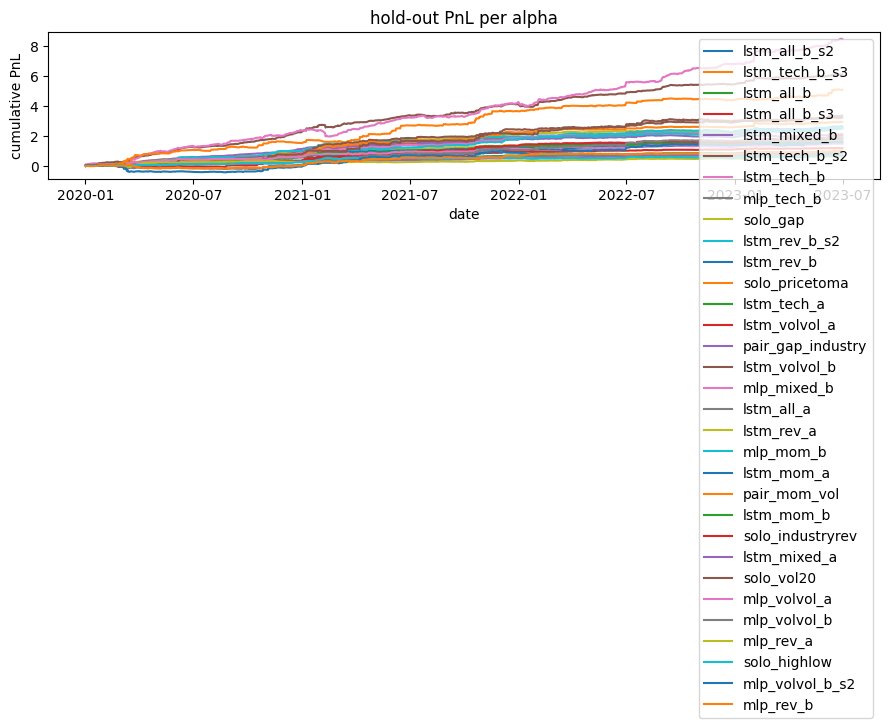

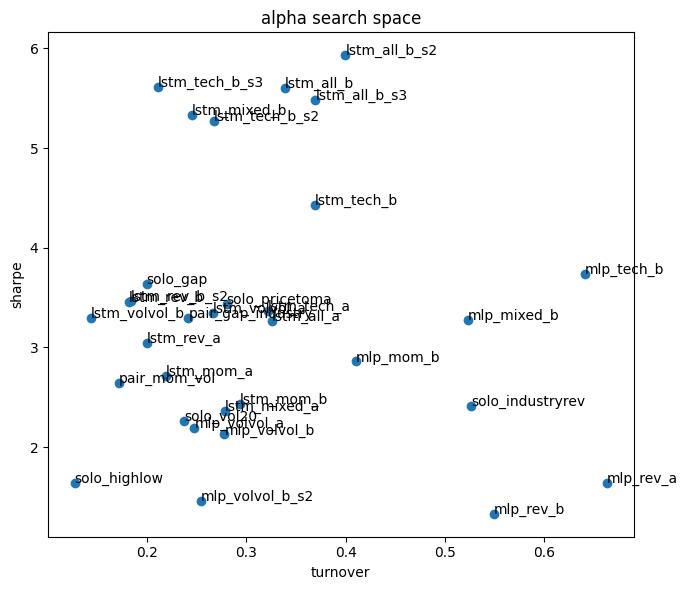

In [7]:
# =====================================================================
# FIXED 4 -- evaluate the alphas   (per alpha, then together)
# =====================================================================
# Per-alpha stats (Sharpe, total PnL, turnover, ...), the
# correlation between alphas, and the combined Sharpe of the best
# un-correlated set -- exactly what the grader does on its hidden
# period.

kpi_table = toolkit.compute_kpis(positions, forward_returns)
print("per-alpha stats:\n", kpi_table.round(4))

print("\nPnL correlation:\n",
      toolkit.pnl_correlation(alphas).round(2))

kept = toolkit.select_uncorrelated(alphas, max_corr=0.5)
print("\nun-alike alphas kept:", kept)
print("combined Sharpe (kept):",
      round(toolkit.combined_sharpe(alphas, kept), 4))

# See the curves while developing (does not affect grading).
toolkit.plot_pnl(alphas, "hold-out PnL per alpha")
toolkit.plot_kpis(kpi_table)

In [8]:
# =====================================================================
# FIXED 5 -- write the submission
# =====================================================================
# For every kept alpha, save two things: the trained model and the
# list of feature names it used.  Submit this folder together with
# your notebook (your feature definitions live in the notebook).
SUBMISSION_DIR = "../output"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

for i in kept:
    torch.save(trained[i], os.path.join(SUBMISSION_DIR, "model_%s.pt" % i))

params = {
    "alphas": kept,
    "feature_sets": {i: feature_sets[i] for i in kept},
}
with open(os.path.join(SUBMISSION_DIR, "params.json"), "w") as handle:
    json.dump(params, handle, indent=2)

print("submission written to", os.path.abspath(SUBMISSION_DIR))

submission written to C:\Users\שקד כהן\Downloads\Applied-Machine-Learning\output
